In [1]:
print("Project 3: Outfit Recommender v1")

Project 3: Outfit Recommender v1


In [38]:
import os
from PIL import Image
import matplotlib.pyplot as plt

In [39]:
# Path to your images folder
IMAGE_FOLDER = "../images"

# List all image files
files = [f for f in os.listdir(IMAGE_FOLDER) if f.endswith(('.png', '.jpg', '.jpeg'))]

# Your style names (same as Project 2)
style_names = {
    0: "Neutral / Minimal",
    1: "Dark / Streetwear",
    2: "Light / Casual"
}

In [40]:
def get_dominant_colors(image_path, k=5):
    image = Image.open(image_path)
    image = image.resize((100, 100))

    pixels = np.array(image).reshape(-1, 3)

    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pixels)

    return kmeans.cluster_centers_

In [41]:
all_features = []

for file in files:
    path = os.path.join(IMAGE_FOLDER, file)

    try:
        colors = get_dominant_colors(path)
        feature = colors.flatten()
        all_features.append(feature)

    except:
        print("Skipped:", file)

all_features = np.array(all_features)

print("Shape:", all_features.shape)

Shape: (25, 15)


In [42]:
style_model = KMeans(n_clusters=3, random_state=42)
style_labels = style_model.fit_predict(all_features)

print(style_labels)

for file, label in zip(files, style_labels):
    print(file, "→ Style Group", label)

[1 2 0 1 1 0 2 0 1 0 2 0 1 1 2 2 1 2 2 1 1 0 1 1 1]
#outfits #fashion #summer #summerstyle.jpg → Style Group 1
30 Effortlessly Chic Outfits to Copy for Summer.jpg → Style Group 2
5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg → Style Group 0
Another Day in Denim.jpg → Style Group 1
download (1).jpg → Style Group 1
download (2).jpg → Style Group 0
download (3).jpg → Style Group 2
download (4).jpg → Style Group 0
download (5).jpg → Style Group 1
download.jpg → Style Group 0
Elegant Spring Outfit Inspo _ Effortlessly Chic Cafe Baddie Look 2026.jpg → Style Group 2
Elegant Street Style _ Fashion Essentials.jpg → Style Group 0
Ellie (@slipintostyle) • Instagram photos and videos.jpg → Style Group 1
Find Out Where To Get The Top.jpg → Style Group 1
Jordan Clarkson Outfits.jpg → Style Group 2
Jordan Clarkson.jpg → Style Group 2
LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg → Style Group 1
lewis hamilton.jpg → Style Group 2
lucyflorals on LTK.jpg → Styl

C:\Users\ousama\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [43]:
from sklearn.metrics.pairwise import cosine_similarity

def recommend_similar_outfits(image_path, top_n=3):
    # Extract features from the input image
    colors = get_dominant_colors(image_path)
    new_feature = colors.flatten()

    # Compare input image with all dataset images using cosine similarity
    similarities = cosine_similarity([new_feature], all_features)[0]

    # Find the style group of the input image
    input_filename = os.path.basename(image_path)
    input_index = files.index(input_filename)
    input_style = style_labels[input_index]

    print("Input style:", style_names[input_style])

    # Sort from highest similarity to lowest
    sorted_indexes = similarities.argsort()[::-1]

    shown = 0

    for index in sorted_indexes:
        file = files[index]

        # Skip the same image
        if file == input_filename:
            continue

        # Only recommend images from the same style group
        if style_labels[index] != input_style:
            continue

        score = similarities[index]

        img_path = os.path.join(IMAGE_FOLDER, file)
        img = Image.open(img_path)

        print(f"{file} → similarity: {score:.3f}")

        plt.imshow(img)
        plt.title(f"{style_names[input_style]}\n{file}\nSimilarity: {score:.3f}")
        plt.axis("off")
        plt.show()

        shown += 1

        if shown >= top_n:
            break

Input style: Dark / Streetwear
Rose.jpg → similarity: 0.964


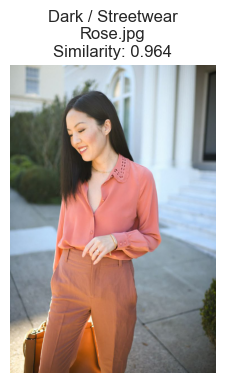

download (5).jpg → similarity: 0.962


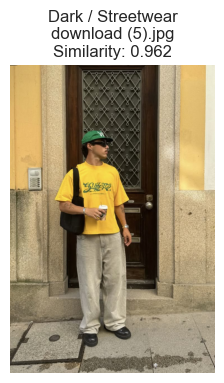

download (1).jpg → similarity: 0.958


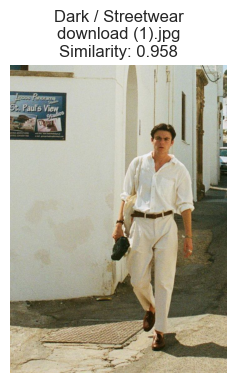

In [44]:
test_image = os.path.join(IMAGE_FOLDER, files[0])
recommend_similar_outfits(test_image, top_n=3)